# Introduction to NeuralHydrology

There are two different ways to use the Python package NeuralHydrology:

1. From the terminal, making use of some high-level entry points (such as `nh-run` and `nh-schedule-runs`)
2. From any other Python file or Jupyter Notebook, using NeuralHydrology's API

For every run that you start, a new folder will be created. This folder is used to store the model and optimizer checkpoints, train data means/stds (needed for scaling during inference), tensorboard log file (can be used to monitor and compare training runs visually), validation results (optionally) and training progress figures (optionally, e.g., model predictions and observations for _n_ random basins). During inference, the evaluation results will also be stored in this directory (e.g., test period results).


### TensorBoard logging
By default, the training progress is logged in TensorBoard files (add `log_tensorboard: False` to the config to disable TensorBoard logging).

To start the TensorBoard dashboard, run:

```
tensorboard --logdir /path/to/run-dir
```

You can also visualize multiple runs at once if you point the `--logdir` to the parent directory (useful for model intercomparison)

## Using NeuralHydrology from the Terminal

### nh-run


Given a run configuration file, you can use the bash command `nh-run` to train/evaluate a model. To train a model, use


```bash
nh-run train --config-file path/to/config.yml
```

to evaluate the model after training, use

```bash
nh-run evaluate --run-dir path/to/run-directory
```

### nh-schedule-runs

If you want to train/evaluate multiple models on different GPUs, you can use the `nh-schedule-runs` command. This tool automatically distributes runs across GPUs and starts a new one, whenever one run finishes.

Calling `nh-schedule-runs` in `train` mode will train one model for each `.yml` file in a directory (or its sub-directories).

```bash
nh-schedule-runs train --directory /path/to/config-dir --runs-per-gpu 2 --gpu_ids 0 1 2 3 
```
Use `-runs-per-gpu` to define the number of models that are simultaneously trained on a _single_ GPU (2 in this case) and `--gpu-ids` to define which GPUs will be used (numbers are ids according to nvidia-smi). In this example, 8 models will train simultaneously on 4 different GPUs.

Calling `nh-schedule-runs` in `evaluate` mode will evaluate all models in all run directories in a given root directory.

```bash
nh-schedule-runs evaluate --directory /path/to/parent-run-dir/ --runs-per-gpu 2 --gpu_ids 0 1 2 3 
```

## Links
A full list of config arguments is listed in the [documentation](https://neuralhydrology.readthedocs.io/en/latest/usage/config.html)

Look at the [API Documentation](https://neuralhydrology.readthedocs.io/en/latest/api/neuralhydrology.html) for a full list of functions/classes you could use.

In [5]:
import pickle
import os
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from neuralhydrology.evaluation import metrics
from neuralhydrology.nh_run import start_run, eval_run

In [12]:
all_runs_dir = '/global/home/users/ann_scheliga/neuralhydrology/runs/'
exp = 'EXP01'

In [13]:
[f for f in os.listdir(all_runs_dir) if exp in f]

['EXP01_1basin_sub_cbr_sub_wi_sw_0508_104855',
 'EXP01_1basin_sub_cbr_no_sw_0508_104934']

## EVALUATION

In [14]:
sw_run_dir = Path(all_runs_dir,"EXP01_1basin_sub_cbr_sub_wi_sw_0508_104855")
print(sw_run_dir)
eval_run(run_dir=sw_run_dir, period="test")
eval_run(run_dir=sw_run_dir, period="train")
eval_run(run_dir=sw_run_dir, period="validation")

/global/home/users/ann_scheliga/neuralhydrology/runs/EXP01_1basin_sub_cbr_sub_wi_sw_0508_104855
# Validation: 100%|██████████| 1/1 [00:00<00:00, 13.99it/s]


In [15]:
nosw_run_dir = Path(all_runs_dir,"EXP01_1basin_sub_cbr_no_sw_0508_104934")
print(nosw_run_dir)
eval_run(run_dir=nosw_run_dir, period="test")
eval_run(run_dir=nosw_run_dir, period="train")
eval_run(run_dir=nosw_run_dir, period="validation")

/global/home/users/ann_scheliga/neuralhydrology/runs/EXP01_1basin_sub_cbr_no_sw_0508_104934
# Validation: 100%|██████████| 1/1 [00:00<00:00, 14.18it/s]


### Load and inspect model predictions

In [16]:
with open(sw_run_dir / "train" / "model_epoch050" / "train_results.p", "rb") as fp:
    sw_train_results = pickle.load(fp)
    
sw_train_results.keys()

dict_keys(['4152450'])

In [17]:
with open(nosw_run_dir / "train" / "model_epoch050" / "train_results.p", "rb") as fp:
    nosw_train_results = pickle.load(fp)
    
nosw_train_results.keys()

dict_keys(['4152450'])

In [18]:
with open(sw_run_dir / "test" / "model_epoch050" / "test_results.p", "rb") as fp:
    sw_test_results = pickle.load(fp)
    
sw_test_results.keys()

dict_keys(['4152450'])

In [19]:
with open(nosw_run_dir / "test" / "model_epoch050" / "test_results.p", "rb") as fp:
    nosw_test_results = pickle.load(fp)
    
nosw_test_results.keys()

dict_keys(['4152450'])

In [20]:
def plot_obs_sim_timeseries(ax, nh_dict,period=''):
    qobs = nh_dict['xr']['Q_obs']
    qsim = nh_dict['xr']['Q_sim']
    
    ax.plot(qobs['date'], qobs, c='k',label='obs')
    ax.plot(qsim['date'], qsim, c='b',label='sim')
    ax.set_ylabel("Discharge (mm/d)")
    ax.set_title(f"{period} period - NSE {nh_dict['NSE']:.3f}")
    values = metrics.calculate_all_metrics(qobs.isel(time_step=-1), qsim.isel(time_step=-1))
    print('----',period, 'METRICS----')
    for key, val in values.items():
        print(f"{key}: {val:.3f}")

---- SW train METRICS----
NSE: 0.636
MSE: 891.083
RMSE: 29.851
KGE: 0.652
Alpha-NSE: 0.714
Beta-KGE: 1.002
Beta-NSE: 0.010
Pearson-r: 0.802
FHV: -18.205
FMS: -26.775
FLV: 85.245
Peak-Timing: 2.000
Peak-MAPE: 15.882
---- SW test METRICS----
NSE: -0.344
MSE: 33953.039
RMSE: 184.264
KGE: -0.864
Alpha-NSE: 0.097
Beta-KGE: 0.798
Beta-NSE: -0.463
Pearson-r: -0.618
FHV: -67.776
FMS: -86.967
FLV: 87.832
Peak-Timing: 2.000
Peak-MAPE: 75.615
---- No SW train METRICS----
NSE: 0.690
MSE: 940.357
RMSE: 30.665
KGE: 0.695
Alpha-NSE: 0.743
Beta-KGE: 1.001
Beta-NSE: 0.003
Pearson-r: 0.836
FHV: -15.172
FMS: -22.310
FLV: 88.112
Peak-Timing: 2.222
Peak-MAPE: 14.405
---- No SW test METRICS----
NSE: 0.023
MSE: 24671.268
RMSE: 157.071
KGE: -0.199
Alpha-NSE: 0.119
Beta-KGE: 0.964
Beta-NSE: -0.083
Pearson-r: 0.188
FHV: -61.683
FMS: -93.039
FLV: -43.112
Peak-Timing: 3.000
Peak-MAPE: 70.273


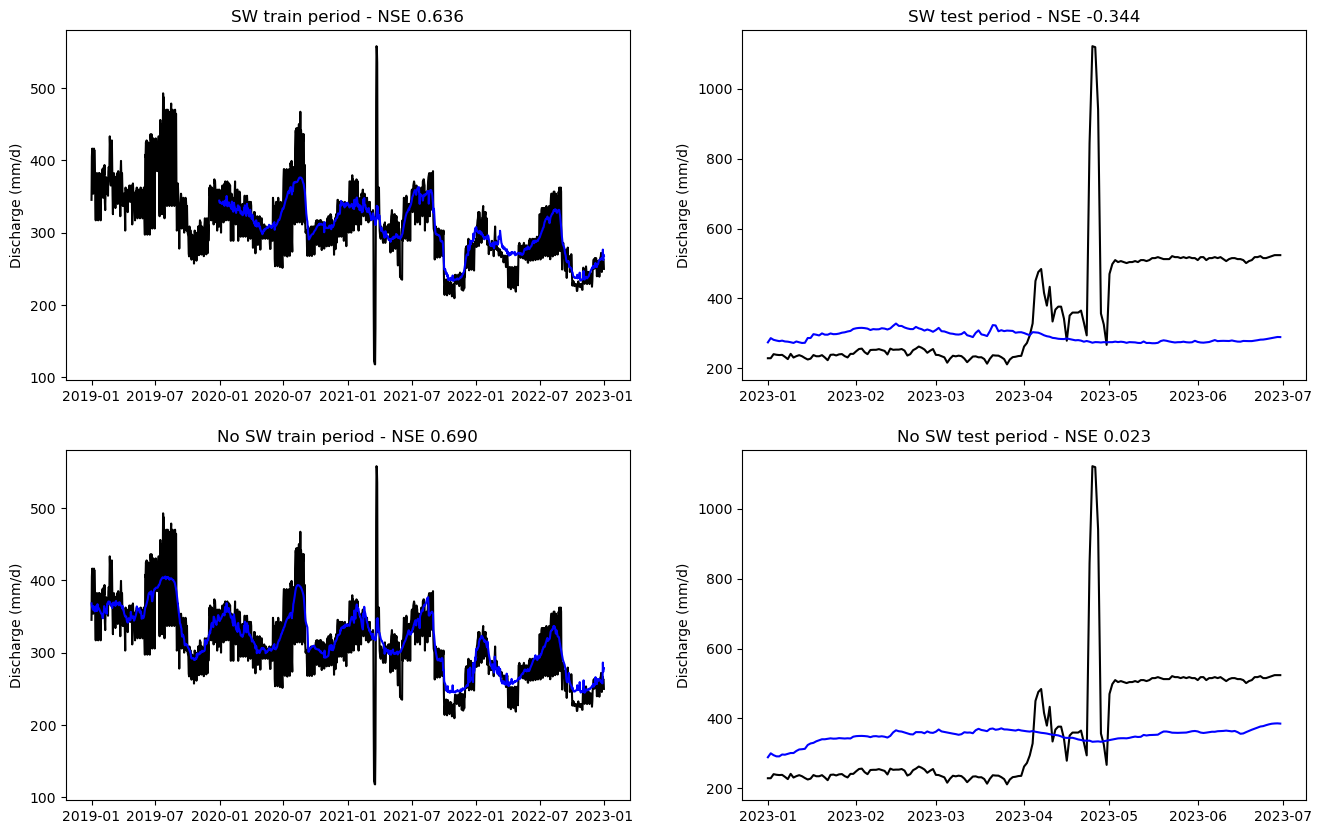

In [21]:
fig, axs = plt.subplots(2,2,figsize=(16,10))

plot_obs_sim_timeseries(axs[0,0],sw_train_results['4152450']['1D'],'SW train')
plot_obs_sim_timeseries(axs[0,1],sw_test_results['4152450']['1D'],'SW test')
plot_obs_sim_timeseries(axs[1,0],nosw_train_results['4152450']['1D'],'No SW train')
plot_obs_sim_timeseries(axs[1,1],nosw_test_results['4152450']['1D'],'No SW test')